In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
dataset = pd.read_csv('creditcard.csv')
X = dataset.iloc[:, :-1].values  
y = dataset.iloc[:, -1].values  
print("First 5 rows of credit card data:")
print(dataset.head())

First 5 rows of credit card data:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [25]:
y_pred = classifier.predict(X_test)


In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[71073     9]
 [   28    92]]

Accuracy Score: 0.9994803516755147

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71082
           1       0.91      0.77      0.83       120

    accuracy                           1.00     71202
   macro avg       0.96      0.88      0.92     71202
weighted avg       1.00      1.00      1.00     71202



In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.25, random_state=0)


In [28]:
sc_pca = StandardScaler()
X_train_pca = sc_pca.fit_transform(X_train_pca)
X_test_pca = sc_pca.transform(X_test_pca)


In [29]:
classifier_pca = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier_pca.fit(X_train_pca, y_train_pca)

KNeighborsClassifier()

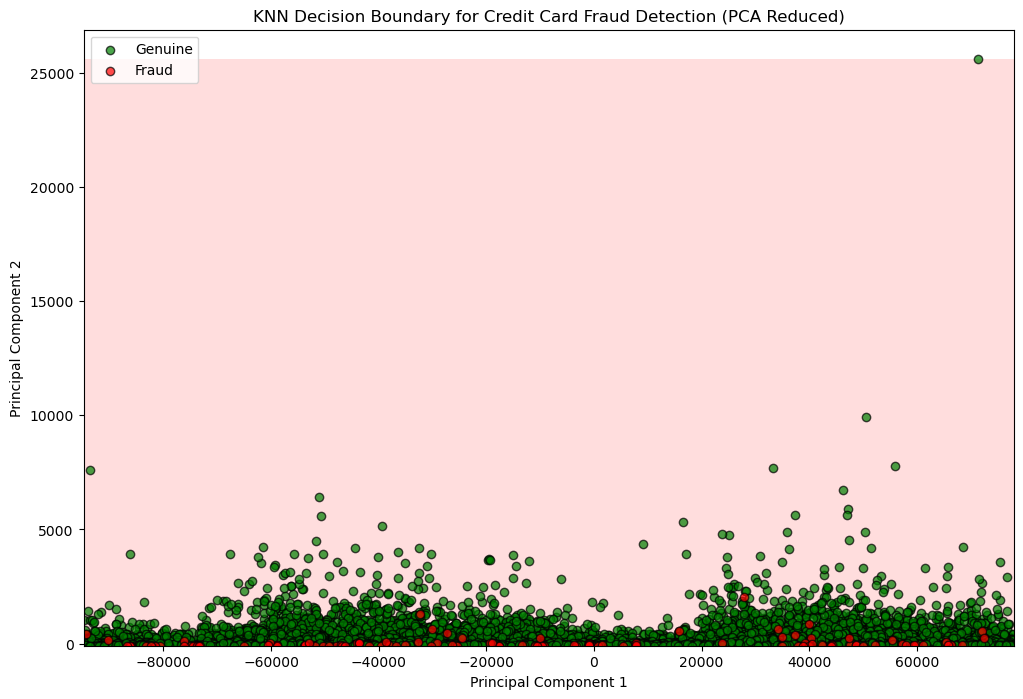


Class Distribution:
Genuine transactions: 284315
Fraud transactions: 492


In [30]:
from matplotlib.colors import ListedColormap

X_set, y_set = sc_pca.inverse_transform(X_test_pca), y_test_pca
x_step = (X_set[:, 0].max() - X_set[:, 0].min()) / 100  # Dynamic step size
y_step = (X_set[:, 1].max() - X_set[:, 1].min()) / 100

X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min()-1, stop=X_set[:, 0].max()+1, step=x_step),
                    np.arange(start=X_set[:, 1].min()-1, stop=X_set[:, 1].max()+1, step=y_step))

plt.figure(figsize=(12, 8))
plt.contourf(X1, X2, classifier_pca.predict(sc_pca.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.4, cmap=ListedColormap(('#FFAAAA', '#AAFFAA')))

plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], color='green', label='Genuine', edgecolor='k', alpha=0.7)
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], color='red', label='Fraud', edgecolor='k', alpha=0.7)

plt.title('KNN Decision Boundary for Credit Card Fraud Detection (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

print("\nClass Distribution:")
print("Genuine transactions:", sum(y==0))
print("Fraud transactions:", sum(y==1))